In [1]:
import pandas as pd
df = pd.read_excel(r"D:\数据挖掘作业\评论数据挖掘\评论数据.xlsx")

# 第一步：数据整理与描述

In [2]:
import pandas as pd
import numpy as np
from datetime import datetime
import re

## 1.1 整理字段

In [3]:
# 为数据添加标准字段名
df = df.rename(columns={'评论': 'comment_text'})
df['comment_id'] = range(1, len(df) + 1)

# 原始数据没有真实的评论时间字段，
# 所以这里不再从评论正文中推断“评论时间”。


## 1.2 去重 & 过滤

In [4]:
print("1. 数据去重与过滤...")
original_count = len(df)

# 删除完全重复的评论
df = df.drop_duplicates(subset=['comment_text']).copy()
duplicate_count = original_count - len(df)
print(f"   - 删除重复评论: {duplicate_count}条")

# 只过滤“整条评论本身就是测试内容”的明显垃圾文本
# 不再因为出现“测试 / 推广 / URL / 邮箱”等词就删除整条评论，
# 因为这些内容可能出现在正常的用户反馈里。
def is_spam_comment(text):
    text = str(text).strip().lower()
    spam_patterns = [
        r'^test$',
        r'^测试$',
        r'^aaaa+$',
        r'^1111+$'
    ]
    return any(re.fullmatch(pattern, text) for pattern in spam_patterns)

df['is_spam'] = df['comment_text'].apply(is_spam_comment)
spam_count = int(df['is_spam'].sum())
print(f"   - 明显测试文本: {spam_count}条")

df = df[~df['is_spam']].drop(columns=['is_spam']).copy()
print(f"   - 过滤后有效评论: {len(df)}条")


1. 数据去重与过滤...
   - 删除重复评论: 32条
   - 明显测试文本: 0条
   - 过滤后有效评论: 3846条


## 1.3 编码处理（确保UTF-8）

In [5]:
def ensure_utf8(text):
    """确保文本为UTF-8编码"""
    if isinstance(text, bytes):
        try:
            return text.decode('utf-8')
        except:
            return text.decode('gbk', errors='ignore')
    return str(text)

df['comment_text'] = df['comment_text'].apply(ensure_utf8)

In [6]:
print("\n2. 数据描述统计...")
print(f"   - 总评论条数: {len(df)}条")

# 评论长度分析
df['comment_length'] = df['comment_text'].astype(str).str.len()
print(f"   - 平均评论长度: {df['comment_length'].mean():.1f}字符")
print(f"   - 最短评论: {df['comment_length'].min()}字符")
print(f"   - 最长评论: {df['comment_length'].max()}字符")

# 按评论长度分组统计
length_bins = [0, 10, 30, 50, 100, 1000]
length_labels = ['超短(0-10)', '短(10-30)', '中(30-50)', '长(50-100)', '超长(100+)']
df['length_category'] = pd.cut(
    df['comment_length'],
    bins=length_bins,
    labels=length_labels
)

print("\n3. 评论长度分布:")
length_dist = df['length_category'].value_counts().sort_index()
for category, count in length_dist.items():
    percentage = count / len(df) * 100
    print(f"   - {category}: {count}条 ({percentage:.1f}%)")

# 这里统计的是“包含该关键词的评论数”，不是关键词出现总次数
keywords = ['数据', '接口', 'API', '下载', '申请', '更新', '错误', '问题']
print("\n4. 包含核心关键词的评论数:")
for keyword in keywords:
    count = df['comment_text'].str.contains(keyword, case=False, na=False).sum()
    percentage = count / len(df) * 100
    print(f"   - '{keyword}': {count}条评论 ({percentage:.1f}%)")

# 只能识别“评论中提到了哪里”，不能把它解释成评论者所在地
print("\n5. 评论中提及地区:")
region_keywords = ['清远', '潮州', '广东', '东莞', '珠海', '佛山', '惠州', '广州', '深圳', '上海']

def detect_region(text):
    for r in region_keywords:
        if r in str(text):
            return r
    return '未明确地区'

df['mentioned_region'] = df['comment_text'].apply(detect_region)
region_dist = df['mentioned_region'].value_counts()

for region, count in region_dist.items():
    percentage = count / len(df) * 100
    print(f"   - {region}: {count}条 ({percentage:.1f}%)")

final_columns = [
    'comment_id', 'comment_text',
    'mentioned_region', 'comment_length', 'length_category'
]

print("\n6. 最终数据结构检查:")
print(f"   - 包含列: {final_columns}")
print(f"   - 数据形状: {df[final_columns].shape}")

df[final_columns].to_csv(
    '整理后评论数据.csv',
    index=False,
    encoding='utf-8-sig'
)

print("\n7. 数据已成功保存到: 整理后评论数据.csv")
print("\n8. 整理后数据样例 (前5条):")
print(
    df[['comment_id', 'mentioned_region', 'comment_length', 'comment_text']]
    .head(5)
    .to_string(index=False)
)



2. 数据描述统计...
   - 总评论条数: 3846条
   - 平均评论长度: 65.3字符
   - 最短评论: 3字符
   - 最长评论: 1299字符

3. 评论长度分布:
   - 超短(0-10): 95条 (2.5%)
   - 短(10-30): 916条 (23.8%)
   - 中(30-50): 1046条 (27.2%)
   - 长(50-100): 1098条 (28.5%)
   - 超长(100+): 690条 (17.9%)

4. 包含核心关键词的评论数:
   - '数据': 2302条评论 (59.9%)
   - '接口': 595条评论 (15.5%)
   - 'API': 266条评论 (6.9%)
   - '下载': 385条评论 (10.0%)
   - '申请': 699条评论 (18.2%)
   - '更新': 228条评论 (5.9%)
   - '错误': 83条评论 (2.2%)
   - '问题': 183条评论 (4.8%)

5. 评论中提及地区:
   - 未明确地区: 3356条 (87.3%)
   - 上海: 260条 (6.8%)
   - 广东: 160条 (4.2%)
   - 广州: 20条 (0.5%)
   - 佛山: 14条 (0.4%)
   - 珠海: 10条 (0.3%)
   - 惠州: 9条 (0.2%)
   - 清远: 5条 (0.1%)
   - 东莞: 5条 (0.1%)
   - 深圳: 4条 (0.1%)
   - 潮州: 3条 (0.1%)

6. 最终数据结构检查:
   - 包含列: ['comment_id', 'comment_text', 'mentioned_region', 'comment_length', 'length_category']
   - 数据形状: (3846, 5)

7. 数据已成功保存到: 整理后评论数据.csv

8. 整理后数据样例 (前5条):
 comment_id mentioned_region  comment_length                                              comment_text
          1            

# 第二步：文本预处理

In [7]:
import warnings
warnings.filterwarnings('ignore')

# 导入所有库
import jieba
import zhconv
from zhon.hanzi import punctuation
import pandas as pd
import re

print("✅ 所有库导入成功！")
print(f"jieba版本：{jieba.__version__}")
print("✅ zhconv 库已成功导入")

✅ 所有库导入成功！
jieba版本：0.42.1
✅ zhconv 库已成功导入


## 2.1 基础清洗

In [8]:
def full_to_half(text):
    """全角转半角"""
    result = ""
    for char in text:
        code = ord(char)
        if code == 12288:
            code = 32
        elif 65281 <= code <= 65374:
            code -= 65248
        result += chr(code)
    return result

def basic_cleaning(text):
    """基础文本清洗"""
    if pd.isna(text) or not isinstance(text, str):
        return ""

    result = str(text)

    # 1. HTML标签
    result = re.sub(r'<.*?>', '', result)

    # 2. URL：保留“这里原本有URL”这个信息，但不保留具体链接
    result = re.sub(r'https?://\S+|www\.\S+', '<URL>', result)

    # 3. 邮箱
    result = re.sub(
        r'\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}\b',
        '<EMAIL>',
        result
    )

    # 4. 电话
    # 注意：不能把“2014-2024”这种年份范围误识别为电话号码
    phone_patterns = [
        r'(?<!\d)1[3-9]\d{9}(?!\d)',              # 手机号
        r'(?<!\d)0\d{2,3}[-\s]?\d{7,8}(?!\d)'    # 带区号固定电话
    ]
    for pattern in phone_patterns:
        result = re.sub(pattern, '<PHONE>', result)

    # 5. 表情符号
    result = re.sub(r'[\U00010000-\U0010ffff]', '', result)

    # 6. 全角转半角
    result = full_to_half(result)

    # 7. 繁体转简体
    result = zhconv.convert(result, 'zh-cn')

    # 8. 过长的流水号 / 数字串
    result = re.sub(r'[A-Za-z0-9_-]{20,}', '<LONG_CODE>', result)
    result = re.sub(r'\d{10,}', '<LONG_NUMBER>', result)

    # 9. URL参数
    result = re.sub(r'[\?&]([a-z_]+)=[^&\s]+', ' <PARAM>', result)

    # 10. 保留中文、英文、数字和基本标点
    result = re.sub(r'[^\u4e00-\u9fa5a-zA-Z0-9\s，。！？；：、<>_]', ' ', result)

    # 11. 合并多余空格
    result = re.sub(r'\s+', ' ', result).strip()

    return result

df['清洗后文本'] = df['comment_text'].apply(basic_cleaning)

print(f"✅ 基础清洗完成！共处理 {len(df)} 条评论")
print("\n前5条清洗对照：")
for i in range(min(5, len(df))):
    print("原文:", df.iloc[i]['comment_text'][:80])
    print("清洗:", df.iloc[i]['清洗后文本'][:80])
    print("-" * 30)


✅ 基础清洗完成！共处理 3846 条评论

前5条清洗对照：
原文: 清远市企业经营异常名录信息《清远市企业经营异常名录信息》下载后发现内容并非清远市的数据，请检查更新。
清洗: 清远市企业经营异常名录信息 清远市企业经营异常名录信息 下载后发现内容并非清远市的数据 请检查更新。
------------------------------
原文: 潮州市全市养老服务机构信息开放信息数据中只有潮州市饶平县的数据，未包含其余区县养老服务机构
清洗: 潮州市全市养老服务机构信息开放信息数据中只有潮州市饶平县的数据 未包含其余区县养老服务机构
------------------------------
原文: 广东省养老机构基本信息下载后xml和json文件均为空
清洗: 广东省养老机构基本信息下载后xml和json文件均为空
------------------------------
原文: 广东省高等教育学校基本信息数据项4是一些代码不是学校地址
清洗: 广东省高等教育学校基本信息数据项4是一些代码不是学校地址
------------------------------
原文: 东莞市房屋租赁变更登记备案办件结果公示信息东莞市房屋租赁变更登记备案办件结果公示信息 下载下来的zip解压不了。
清洗: 东莞市房屋租赁变更登记备案办件结果公示信息东莞市房屋租赁变更登记备案办件结果公示信息 下载下来的zip解压不了。
------------------------------


## 2.2 分词与词性筛选

In [9]:
import pandas as pd
import re
import jieba
import jieba.posseg as pseg

# 2.2.1 自定义词典
custom_words = ['积分落户', '异地就医', '医保统筹', '垃圾分类', '社保', 'API', '接口', '数据质量']
for word in custom_words:
    jieba.add_word(word, tag='n')

# 如果有元数据词典，就把它与 Notebook 放在同一文件夹
try:
    with open("元数据词典.txt", "r", encoding="utf-8") as f:
        for line in f:
            if line.strip():
                jieba.add_word(line.strip(), tag='n')
except FileNotFoundError:
    print("未找到元数据词典.txt，本次只使用上面的自定义词。")

# 2.2.2 停用词
stopwords = {
    '的', '了', '和', '在', '是', '我', '有', '就',
    '您好', '你好', '谢谢', '感谢',
    '数据', '平台',
    # 清洗阶段留下的占位符，不希望它们进入主题模型
    'URL', 'EMAIL', 'PHONE', 'LONG', 'CODE', 'NUMBER', 'PARAM'
}

# 2.2.3 分词 + 词性筛选
ALLOWED_POS = {
    'n', 'nr', 'ns', 'nt', 'nz', 'nl', 'ng',
    'v', 'vd', 'vn', 'a', 'ad', 'an', 'eng', 'i', 'l'
}

def advanced_process(text):
    if not isinstance(text, str) or not text.strip():
        return ""

    # 只做分词前必要的字符整理，不再重复做一整套清洗
    text = re.sub(r'[^\u4e00-\u9fa5a-zA-Z0-9]', ' ', text)

    words = pseg.lcut(text)
    tokens = [
        w.word for w in words
        if w.flag in ALLOWED_POS
        and len(w.word) > 1
        and w.word not in stopwords
    ]
    return " ".join(tokens)

# 关键：这里使用“清洗后文本”，而不是重新用原始 comment_text
df['clean_tokens'] = df['清洗后文本'].apply(advanced_process)

test_case = "我需要查询异地就医和医保统筹的相关API接口，数据开放平台很好用"
print("🔍 验证结果:")
print(f"处理后: {advanced_process(test_case)}")

df.to_csv('预处理后数据.csv', index=False, encoding='utf-8-sig')


Building prefix dict from the default dictionary ...
Loading model from cache C:\Users\Lenovo\AppData\Local\Temp\jieba.cache
Loading model cost 0.550 seconds.
Prefix dict has been built successfully.


🔍 验证结果:
处理后: 需要 查询 异地就医 医保统筹 相关 API 接口 开放平台


## 2.3 停用词处理

In [10]:
# 2.3 停用词处理
print("\n" + "="*40)
print("2.3 停用词处理")
print("="*40)

def remove_stopwords(word_list):
    """过滤停用词、单字词及无意义字符"""
    if isinstance(word_list, str):
        word_list = word_list.split()

    if not word_list:
        return []

    stopwords = {
        '的', '了', '和', '在', '是', '我', '有', '就', '不', '人', '都', '一', '个', '上', '也', '很', '到', '说',
        '我们', '你们', '他们', '您好', '你好', '谢谢', '请问', '是否', '可以', '麻烦', '感谢', '希望', '建议',
        '贵平台', '开放平台', '数据开放', '数据平台', '数据开放网', '互动交流', '交流板块', '评论', '数据集',
        'URL', 'EMAIL', 'PHONE', 'LONG', 'CODE', 'NUMBER', 'PARAM','信息', '需要', '相关', '进行', '情况',
        '提供', '使用', '查询', '获取', '没有'
    }

    return [word for word in word_list if word not in stopwords and len(word) > 1]

input_col = 'clean_tokens' if 'clean_tokens' in df.columns else '分词结果'
print(f"正在从列 [{input_col}] 提取数据进行停用词处理...")

df['分词结果_最终'] = df[input_col].apply(remove_stopwords)

# 过滤空文本后，一定重置索引。
# 后面 corpus[0] 才会和 df.loc[0] 指向同一条评论。
df = df[df['分词结果_最终'].map(len) > 0].reset_index(drop=True)

total_comments = len(df)
avg_word_count = df['分词结果_最终'].map(len).mean()

print("✅ 停用词处理完成")
print(f"\n预处理最终报表:")
print(f"   有效评论数: {total_comments} 条")
print(f"   每条评论平均保留核心词: {avg_word_count:.1f} 个")
print(f"   最终数据样例: {df['分词结果_最终'].iloc[0]}")



2.3 停用词处理
正在从列 [clean_tokens] 提取数据进行停用词处理...
✅ 停用词处理完成

预处理最终报表:
   有效评论数: 3836 条
   每条评论平均保留核心词: 14.4 个
   最终数据样例: ['清远市', '企业', '经营', '名录', '清远市', '企业', '经营', '名录', '下载', '发现', '内容', '清远市', '检查']


# 第三步：探索性分析（EDA）

## 3.1 词频统计

In [11]:
from collections import Counter
# 获取所有分词结果
all_words = []
for word_list in df['分词结果_最终']:
    all_words.extend(word_list)

# 统计词频
word_freq = Counter(all_words)
total_words = len(all_words)

print(f"总词数: {total_words}")
print(f"唯一词数: {len(word_freq)}")

# 显示前30个高频词
print(f"\n 前30个高频词:")
top_words = word_freq.most_common(30)
for i, (word, freq) in enumerate(top_words, 1):
    percentage = freq / total_words * 100
    print(f"  {i:2d}. {word:<8} {freq:>4}次 ({percentage:.2f}%)")

# 领域关键词分析
print(f"\n 领域关键词统计:")
domain_keywords = ['医保', '疫情', '公交', '旅游', '垃圾分类', '接口', '下载', '文件', '损坏', '更新']
for keyword in domain_keywords:
    if keyword in word_freq:
        freq = word_freq[keyword]
        percentage = freq / total_words * 100
        print(f"  {keyword:<6}: {freq:>4}次 ({percentage:.2f}%)")

# 主题雏形分析
print(f"\n 主题雏形识别:")
high_freq_words = [word for word, freq in word_freq.most_common(50)]
print("高频词中可能包含的主题:")
if '数据' in high_freq_words:
    print("数据服务类")
if '医保' in high_freq_words or '医疗' in high_freq_words:
    print(" 医疗健康类")  
if '公交' in high_freq_words or '交通' in high_freq_words:
    print("交通出行类")
if '垃圾' in high_freq_words or '环境' in high_freq_words:
    print("环境治理类")
if '接口' in high_freq_words or 'API' in high_freq_words:
    print("技术服务类")

print(f"\n✅ 词频统计完成")

总词数: 55324
唯一词数: 6913

 前30个高频词:
   1. 申请       1048次 (1.89%)
   2. 接口        959次 (1.73%)
   3. 下载        496次 (0.90%)
   4. 调用        470次 (0.85%)
   5. 浙江省       455次 (0.82%)
   6. 研究        421次 (0.76%)
   7. 开放        414次 (0.75%)
   8. 企业        362次 (0.65%)
   9. 论文        323次 (0.58%)
  10. 无法        314次 (0.57%)
  11. 统计        309次 (0.56%)
  12. 数量        300次 (0.54%)
  13. 服务        298次 (0.54%)
  14. API       297次 (0.54%)
  15. 上海市       256次 (0.46%)
  16. 相关数据      248次 (0.45%)
  17. 广东省       233次 (0.42%)
  18. 旅游        230次 (0.42%)
  19. 贵州省       220次 (0.40%)
  20. 问题        212次 (0.38%)
  21. 认证        205次 (0.37%)
  22. 单位        203次 (0.37%)
  23. 文件        195次 (0.35%)
  24. 时间        194次 (0.35%)
  25. 公开        193次 (0.35%)
  26. 显示        193次 (0.35%)
  27. 人数        187次 (0.34%)
  28. 年鉴        178次 (0.32%)
  29. 用于        178次 (0.32%)
  30. 需求        177次 (0.32%)

 领域关键词统计:
  疫情    :   49次 (0.09%)
  公交    :   24次 (0.04%)
  旅游    :  230次 (0.42%)
  垃圾分类  :   10

## 3.2 共现词组

In [12]:
def get_ngrams(word_list, n=2):
    return [' '.join(word_list[i:i+n]) for i in range(len(word_list)-n+1)]

# 统计所有bi-gram和tri-gram
bigrams = []
trigrams = []
for words in df['分词结果_最终']:
    if len(words) >= 2:
        bigrams.extend(get_ngrams(words, 2))
    if len(words) >= 3:
        trigrams.extend(get_ngrams(words, 3))

# 统计高频bi-gram
bigram_freq = Counter(bigrams)
print(" 高频bi-gram（前20个）:")
top_bigrams = bigram_freq.most_common(20)
for i, (phrase, freq) in enumerate(top_bigrams, 1):
    print(f"  {i:2d}. {phrase:<20} {freq:>3}次")

# 统计高频tri-gram
trigram_freq = Counter(trigrams)
print(f"\n 高频tri-gram（前15个）:")
top_trigrams = trigram_freq.most_common(15)
for i, (phrase, freq) in enumerate(top_trigrams, 1):
    print(f"  {i:2d}. {phrase:<25} {freq:>3}次")

print(f"\n 共现词组分析完成")

 高频bi-gram（前20个）:
   1. 接口 调用                192次
   2. API 接口               186次
   3. 统计 年鉴                157次
   4. 论文 研究                108次
   5. qq com                90次
   6. 接口 申请                 83次
   7. 实名 认证                 77次
   8. api 接口                68次
   9. 邮箱 qq                 54次
  10. 无法 下载                 51次
  11. 浙江省 地级市               51次
  12. 申请 开放                 50次
  13. 调用 接口                 50次
  14. 申请 接口                 47次
  15. 课题 研究                 43次
  16. 接口 文档                 43次
  17. 公开 统计                 41次
  18. 公共数据 开放               41次
  19. 服务 贸易                 39次
  20. 下载 文件                 34次

 高频tri-gram（前15个）:
   1. 邮箱 qq com                  54次
   2. API 接口 申请                  41次
   3. 公开 统计 年鉴                   40次
   4. API 接口 调用                  36次
   5. api 接口 调用                  34次
   6. 统计 年鉴 官方网站                 33次
   7. 权限 认证 失败                   32次
   8. 统计局 公开 统计                  29次
   9. 论文 研究 统计局           

## 3.3  文本长度分析

In [13]:
# 计算每条评论的分词数
df['分词数量'] = df['分词结果_最终'].str.len()
# 基本统计
total_comments = len(df)
avg_words = df['分词数量'].mean()
max_words = df['分词数量'].max()
min_words = df['分词数量'].min()
print(f" 文本长度统计:")
print(f"  总评论数: {total_comments}")
print(f"  平均分词数: {avg_words:.1f}")
print(f"  最多分词数: {max_words}")
print(f"  最少分词数: {min_words}")
# 长度分布统计
short_comments = len(df[df['分词数量'] <= 3])
medium_comments = len(df[(df['分词数量'] > 3) & (df['分词数量'] <= 10)])
long_comments = len(df[df['分词数量'] > 10])
print(f"\n 长度分布:")
print(f"  短文本(≤3词): {short_comments}条 ({short_comments/total_comments*100:.1f}%)")
print(f"  中文本(4-10词): {medium_comments}条 ({medium_comments/total_comments*100:.1f}%)")
print(f"  长文本(>10词): {long_comments}条 ({long_comments/total_comments*100:.1f}%)")
# 检查极短文本
if short_comments > 0:
    print(f"\n  极短文本样例:")
    short_samples = df[df['分词数量'] <= 3].head(3)
    for i, row in short_samples.iterrows():
        print(f"  - {row['分词结果_最终']} (原句: {row['comment_text'][:30]}...)")
else:
    print(f"\n✅ 无极短文本，数据质量良好")
print(f"\n✅ 文本长度分析完成")

 文本长度统计:
  总评论数: 3836
  平均分词数: 14.4
  最多分词数: 145
  最少分词数: 1

 长度分布:
  短文本(≤3词): 273条 (7.1%)
  中文本(4-10词): 1526条 (39.8%)
  长文本(>10词): 2037条 (53.1%)

  极短文本样例:
  - ['广东省', '高考', '统计'] (原句: 广东省高考信息数据统计2020年数据未更新。...)
  - ['气象预报', '预报'] (原句: 气象预报数据最新的预报数据...)
  - ['申请', '企业资质', '资质'] (原句: 申请企业资质信息资质信息...)

✅ 文本长度分析完成


# 第四步 文本表示方式选择 —（TF-IDF 方案）

In [14]:
import warnings
warnings.filterwarnings('ignore')
from sklearn.feature_extraction.text import TfidfVectorizer

# TF-IDF 这一部分只做补充探索。
# 后面的 LDA 实际使用的是 Bag-of-Words（Dictionary + doc2bow），不是 TF-IDF 矩阵。
df['processed_text'] = df['分词结果_最终'].apply(
    lambda x: " ".join(x) if isinstance(x, list) else ""
)

tfidf_vectorizer = TfidfVectorizer(
    min_df=5,
    max_df=0.8,
    token_pattern=r"(?u)\b\w+\b"
)

tfidf_matrix = tfidf_vectorizer.fit_transform(df['processed_text'])

print("TF-IDF 向量构建完成")
print("文档数:", tfidf_matrix.shape[0])
print("词维度:", tfidf_matrix.shape[1])

feature_names = tfidf_vectorizer.get_feature_names()


D:\Anaconda3\lib\site-packages\sklearn\feature_extraction\image.py:167: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  dtype=np.int):


TF-IDF 向量构建完成
文档数: 3836
词维度: 1480


# 第五步 主题建模与主题数选择 

In [15]:
!pip install gensim -i https://pypi.tuna.tsinghua.edu.cn/simple

Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple


In [16]:
import gensim
from gensim import corpora
from gensim.models import CoherenceModel

# 准备语料
texts = df['分词结果_最终'].tolist()

# 构建词典
dictionary = corpora.Dictionary(texts)

# 过滤低频 & 高频
dictionary.filter_extremes(no_below=5, no_above=0.8)

# 语料向量化
corpus = [dictionary.doc2bow(text) for text in texts]

print("词典大小:", len(dictionary))
print("语料数量:", len(corpus))
# 删除词典过滤后变成空词袋的评论
valid_idx = [i for i, bow in enumerate(corpus) if len(bow) > 0]

df = df.iloc[valid_idx].reset_index(drop=True)
texts = [texts[i] for i in valid_idx]
corpus = [corpus[i] for i in valid_idx]

print("删除空词袋后：")
print("df评论数：", len(df))
print("texts数量：", len(texts))
print("corpus数量：", len(corpus))

词典大小: 1479
语料数量: 3836
删除空词袋后：
df评论数： 3817
texts数量： 3817
corpus数量： 3817


## 计算不同K的Coherence

In [17]:
def compute_coherence(k):
    lda_temp = gensim.models.LdaModel(
        corpus=corpus,
        id2word=dictionary,
        num_topics=k,
        random_state=42,
        passes=20,
        alpha='auto'
    )

    coherence_model = CoherenceModel(
        model=lda_temp,
        texts=texts,
        dictionary=dictionary,
        coherence='c_v'
    )
    return coherence_model.get_coherence()

candidate_k = [5, 6, 7, 8, 9, 10]
coherence_values = []

print("不同主题数的 Coherence：")
for k in candidate_k:
    cv = compute_coherence(k)
    coherence_values.append(cv)
    print(f"K = {k}, Coherence = {cv:.4f}")


不同主题数的 Coherence：
K = 5, Coherence = 0.4661
K = 6, Coherence = 0.4251
K = 7, Coherence = 0.4026
K = 8, Coherence = 0.4272
K = 9, Coherence = 0.4112
K = 10, Coherence = 0.4511


# 第六步 最终LDA建模 + 主题解释

## 6.1 选择最佳K值

In [18]:
# 根据当前重新清洗后的数据，选择 Coherence 最高的 K
best_k = candidate_k[coherence_values.index(max(coherence_values))]

lda_model = gensim.models.LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=best_k,
    random_state=42,
    passes=20,
    alpha='auto'
)

print(f"最终主题模型训练完成（K = {best_k}）")
print(f"最高 Coherence = {max(coherence_values):.4f}")


最终主题模型训练完成（K = 5）
最高 Coherence = 0.4661


## 6.2 主题Top关键词


各主题 Top 关键词：
  主题1:  接口，下载，调用，无法，申请，认证，显示，服务，返回，API，问题，文件
  主题2:  接口，开放，API，应用，调用，申请，企业，山东省，com，健康，邮箱，格式
  主题3:  上海市，开放，数量，机构，申请，目录，人数，研究，公共数据，上海，时间，分析
  主题4:  浙江省，研究，论文，统计，旅游，相关数据，年鉴，研究生，毕业论文，贵州省，数量，申请
  主题5:  申请，企业，广东省，提交，开放，需求，审核，地址，回复，查看，公司，服务


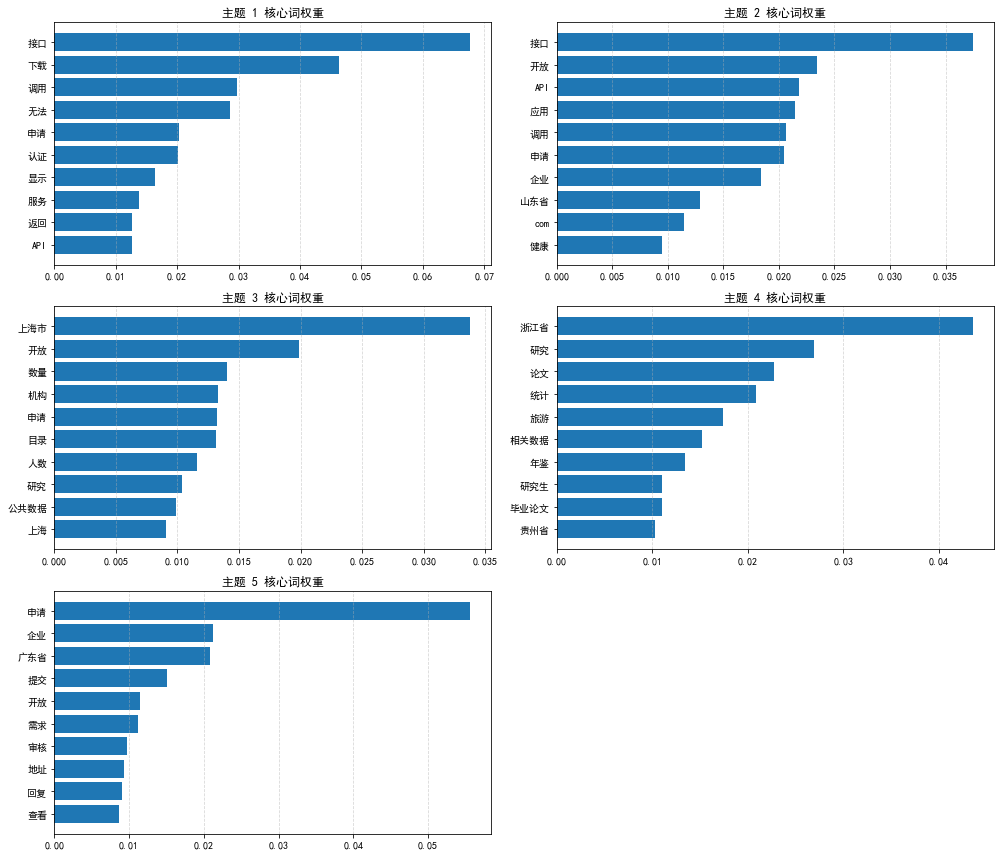

In [19]:
print("\n各主题 Top 关键词：")
for i in range(best_k):
    terms = lda_model.show_topic(i, topn=12)
    keywords = [w for w, p in terms]
    print(f"  主题{i+1}: ", "，".join(keywords))

import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['SimHei']

n_cols = 2
n_rows = (best_k + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4*n_rows))
axes = axes.flatten()

for i in range(best_k):
    words = lda_model.show_topic(i, 10)
    word_names = [w[0] for w in words]
    word_weights = [w[1] for w in words]
    axes[i].barh(word_names[::-1], word_weights[::-1])
    axes[i].set_title(f'主题 {i+1} 核心词权重')
    axes[i].grid(axis='x', linestyle='--', alpha=0.5)

for j in range(best_k, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()


## 6.3 抽取代表评论（用于命名主题）

In [20]:
import numpy as np

topic_comments = {i: [] for i in range(best_k)}

for idx, bow in enumerate(corpus):
    topic_prob = lda_model.get_document_topics(bow, minimum_probability=0)
    main_topic, main_prob = max(topic_prob, key=lambda x: x[1])

    # 保存评论索引 + 该评论属于主主题的概率
    topic_comments[main_topic].append((idx, main_prob))

# 每个主题取“主主题概率最高”的8条，更有代表性
for t in range(best_k):
    topic_comments[t].sort(key=lambda x: x[1], reverse=True)

    print(f"\n===== 主题 {t+1} 代表评论 =====")
    for idx, prob in topic_comments[t][:8]:
        print(f" [{prob:.3f}]", df.loc[idx, 'comment_text'][:80])



===== 主题 1 代表评论 =====
 [0.991] 接口调用失败，显示300无数据返回，后面显示服务调用次数配额已用尽由于数据量大，页面下载后得到的cvs格式文件中，仅能显示前100万条。于是选择在线调用，但在线
 [0.989] 关于接口【四川省大中型水库水情】只有当天申请通过后能使用的问题【四川省大中型水库水情】接口申请的使用期限为：【2025-05-22-2025-06-30】，授权
 [0.989] 自治区交通运输厅的道路运输经营许可证、道路运输证信息接口无法连接至原始服务您好，本单位正在使用中的道路运输经营许可证、道路运输证信息接口近2日无法正常使用，提示
 [0.988] 医疗器械注册证说明书附件存储地址下载不了医疗器械注册证说明书附件存储地址下载不了，例如这个地址：http://oss-cn-hangzhou-zjzwy01-d
 [0.988] 关于接口【四川省大中型水库水情】调用失败问题已申请【四川省大中型水库水情】该账号的权限。在通过后的当天，根据文档调用该接口，可正常返回数据。在第三天，在本人代码
 [0.986] 请问下【济宁市出租车GPS数据查询服务】这个数据需要怎么下载/申请这个数据一直显示错误，请问怎么下载相应数据呢？另外申请相应的API接口，请审核一下，谢谢！
{
 [0.986] 接口调用失效，在线接口调用也失效。返回错误。在线接口调用，返回
{
    &quot;code&quot;: &quot;300&quot;,
    &qu
 [0.986] 您好，调用API接口 总是返回 "服务已降级"的异常信息  ，想咨询 是什么原因？谢谢。您好，调用API接口 总是返回 {"code":"300","msg":

===== 主题 2 代表评论 =====
 [0.985] 建议资源的文件命名再规范一些例如“全省人口数、户数（户籍）”内容中有3个资源文件：《3-4全省人口数、户数（户籍）.xls》、《全省人口数、户数（户籍）_C_Y
 [0.984] 申请高考数据2022物理类,2021物理类,2020物理类广东省2022年高考普通类（物理）分数段统计表（含本、专科层次加分）.xls 广东省2021年高考普通
 [0.984] 请求获取2022、2023、2024届广西区内开设电子信息工程技术、移动通信技术、应用电子

# 第七部分 主题结构量化分析


主题占比：
  主题1: 1047条 (27.43%)
  主题2: 468条 (12.26%)
  主题3: 705条 (18.47%)
  主题4: 891条 (23.34%)
  主题5: 706条 (18.50%)


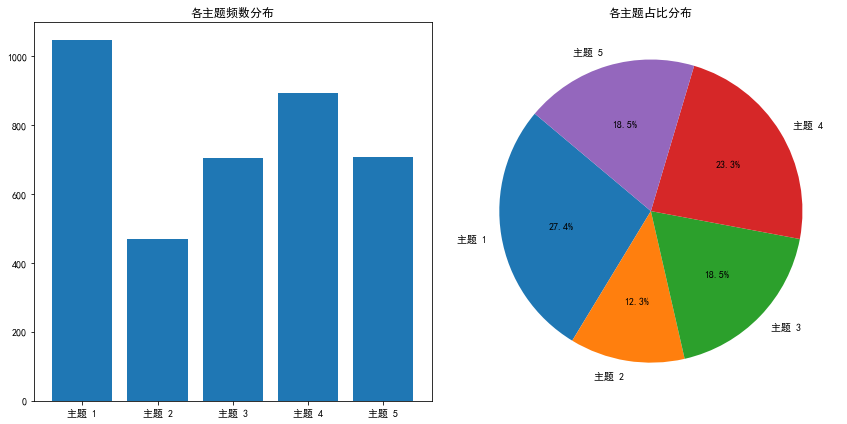

In [21]:
import numpy as np
import matplotlib.pyplot as plt

topic_distribution = np.zeros(best_k)

for bow in corpus:
    topic_prob = lda_model.get_document_topics(bow)
    main_topic = max(topic_prob, key=lambda x: x[1])[0]
    topic_distribution[main_topic] += 1

total = len(corpus)

print("\n主题占比：")
for i in range(best_k):
    percent = topic_distribution[i] / total * 100
    print(f"  主题{i+1}: {int(topic_distribution[i])}条 ({percent:.2f}%)")

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.figure(figsize=(12, 6))

labels = [f"主题 {i+1}" for i in range(best_k)]
sizes = topic_distribution

plt.subplot(1, 2, 1)
plt.bar(labels, sizes)
plt.title("各主题频数分布")

plt.subplot(1, 2, 2)
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140)
plt.title("各主题占比分布")

plt.tight_layout()
plt.show()


In [22]:
print("df评论数：", len(df))
print("texts数量：", len(texts))
print("corpus数量：", len(corpus))

empty_bow = [i for i, bow in enumerate(corpus) if len(bow) == 0]
print("空词袋数量：", len(empty_bow))
print("空词袋索引：", empty_bow[:20])

df评论数： 3817
texts数量： 3817
corpus数量： 3817
空词袋数量： 0
空词袋索引： []


# 第八部分 可靠性与稳健性检验

## 8.1 再次计算Coherence确认模型稳定

In [23]:
# 8.1 回顾前面已经计算过的 Coherence
# 不再重新训练一套参数不同的模型，避免前后口径不一致。
coherence_results = list(zip(candidate_k, coherence_values))

print("不同 K 下 Coherence：")
for k, cv in coherence_results:
    print(f"K={k}, Coherence={cv:.4f}")


不同 K 下 Coherence：
K=5, Coherence=0.4661
K=6, Coherence=0.4251
K=7, Coherence=0.4026
K=8, Coherence=0.4272
K=9, Coherence=0.4112
K=10, Coherence=0.4511


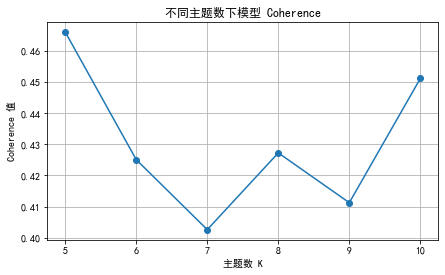

In [24]:
import matplotlib.pyplot as plt

k_list = [x[0] for x in coherence_results]
cv_list = [x[1] for x in coherence_results]

plt.figure(figsize=(7,4))
plt.plot(k_list, cv_list, marker='o')
plt.title("不同主题数下模型 Coherence")
plt.xlabel("主题数 K")
plt.ylabel("Coherence 值")
plt.grid(True)
plt.show()


## 8.2 重复建模一致性检验（随机性鲁棒性）

In [25]:
from gensim.models import CoherenceModel

seed_list = [10, 20, 30, 40, 50]
repeat_coherence = []

print("不同随机种子下模型稳定性检测：")
for seed in seed_list:
    lda_temp = gensim.models.LdaModel(
        corpus=corpus,
        id2word=dictionary,
        num_topics=best_k,
        random_state=seed,
        passes=20,
        alpha='auto'
    )

    cm = CoherenceModel(
        model=lda_temp,
        texts=texts,
        dictionary=dictionary,
        coherence='c_v'
    )

    cv = cm.get_coherence()
    repeat_coherence.append(cv)
    print(f"random_state={seed}, Coherence={cv:.4f}")

print("\n平均 Coherence:", sum(repeat_coherence) / len(repeat_coherence))
print("最大波动:", max(repeat_coherence) - min(repeat_coherence))


不同随机种子下模型稳定性检测：
random_state=10, Coherence=0.4141
random_state=20, Coherence=0.4632
random_state=30, Coherence=0.4602
random_state=40, Coherence=0.4560
random_state=50, Coherence=0.3947

平均 Coherence: 0.43763972387876304
最大波动: 0.06847240241963953


## 8.3 语义稳定性检验

In [26]:
import numpy as np

def get_topic_keywords(model, topn=10):
    topics = []
    for i in range(best_k):
        terms = model.show_topic(i, topn=topn)
        topics.append(set(w for w, p in terms))
    return topics

models_topics = []

for seed in seed_list:
    lda_temp = gensim.models.LdaModel(
        corpus=corpus,
        id2word=dictionary,
        num_topics=best_k,
        random_state=seed,
        passes=20,
        alpha='auto'
    )
    models_topics.append(get_topic_keywords(lda_temp))

def jaccard(a, b):
    return len(a & b) / len(a | b)

print("\n主题关键词稳定性（Jaccard）：")

for t in range(best_k):
    base_topic = models_topics[0][t]
    sims = []

    for m in range(1, len(models_topics)):
        # LDA 的主题编号可能交换，所以和另一模型中“最相似的主题”比较
        sim_list = [
            jaccard(base_topic, other_topic)
            for other_topic in models_topics[m]
        ]
        sims.append(max(sim_list))

    print(f"主题{t+1} 平均相似度: {np.mean(sims):.3f}")



主题关键词稳定性（Jaccard）：
主题1 平均相似度: 0.273
主题2 平均相似度: 0.511
主题3 平均相似度: 0.315
主题4 平均相似度: 0.607
主题5 平均相似度: 0.179


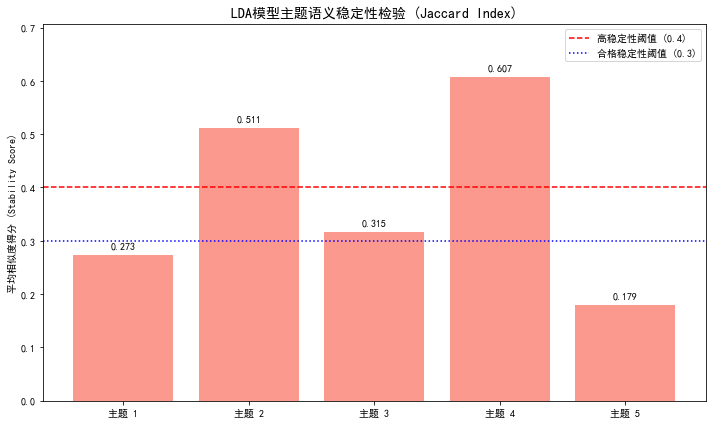

In [27]:
import matplotlib.pyplot as plt
jaccard_scores = []
for t in range(best_k):
    base_topic = models_topics[0][t]
    sims = []
    for m in range(1, len(models_topics)):
        sim_list = [jaccard(base_topic, other_topic) for other_topic in models_topics[m]]
        sims.append(max(sim_list))
    jaccard_scores.append(np.mean(sims))
plt.rcParams['font.sans-serif'] = ['SimHei'] 
plt.figure(figsize=(10, 6))

# 画柱状图
x_labels = [f"主题 {i+1}" for i in range(best_k)]
bars = plt.bar(x_labels, jaccard_scores, color='salmon', alpha=0.8)
# 在柱子上标注具体分数
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f'{yval:.3f}', ha='center', va='bottom')
plt.axhline(y=0.4, color='red', linestyle='--', label='高稳定性阈值 (0.4)')
plt.axhline(y=0.3, color='blue', linestyle=':', label='合格稳定性阈值 (0.3)')

plt.title("LDA模型主题语义稳定性检验 (Jaccard Index)", fontsize=14)
plt.ylabel("平均相似度得分 (Stability Score)")
plt.ylim(0, max(jaccard_scores) + 0.1) # 留出顶部空间
plt.legend()
plt.tight_layout()
plt.show()

## LDA 的可视化结果

In [28]:
import pyLDAvis
import pyLDAvis.gensim
import warnings

warnings.filterwarnings('ignore')

vis_data = pyLDAvis.gensim.prepare(
    lda_model,       
    corpus,          
    dictionary,      
    sort_topics=False, 
    n_jobs=1        
)

pyLDAvis.display(vis_data)

D:\Anaconda3\lib\site-packages\sklearn\linear_model\least_angle.py:35: DeprecationWarning: `np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  eps=np.finfo(np.float).eps,
D:\Anaconda3\lib\site-packages\sklearn\linear_model\least_angle.py:597: DeprecationWarning: `np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  eps=np.finfo(np.float).eps, copy_X=True, fit_path=True,
D:\Anaconda3\lib\site